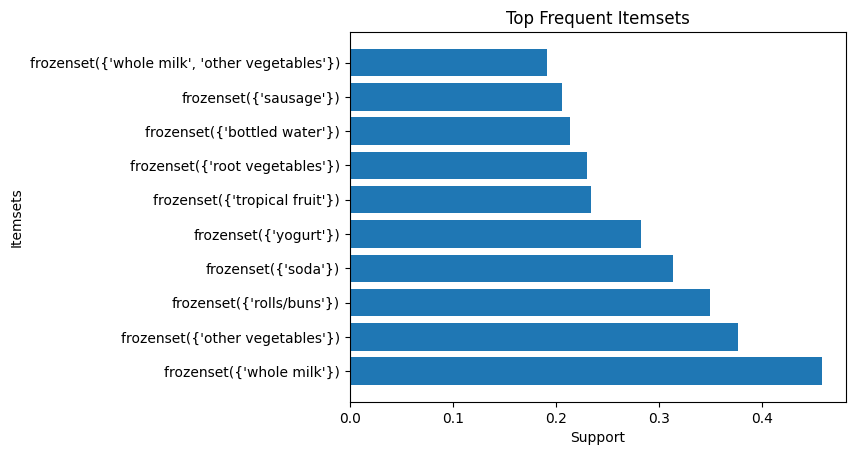

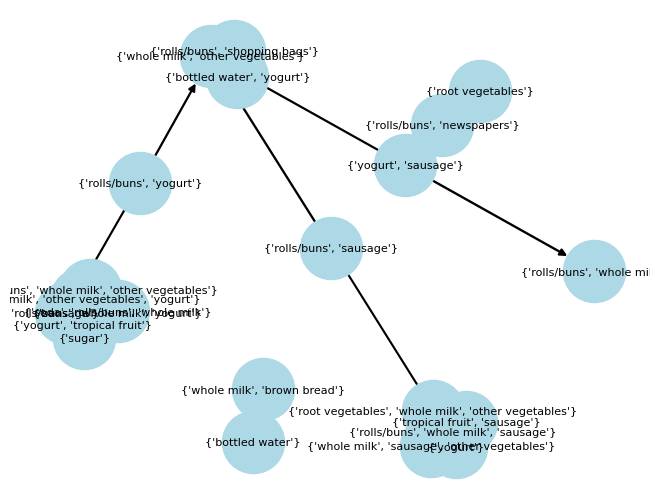

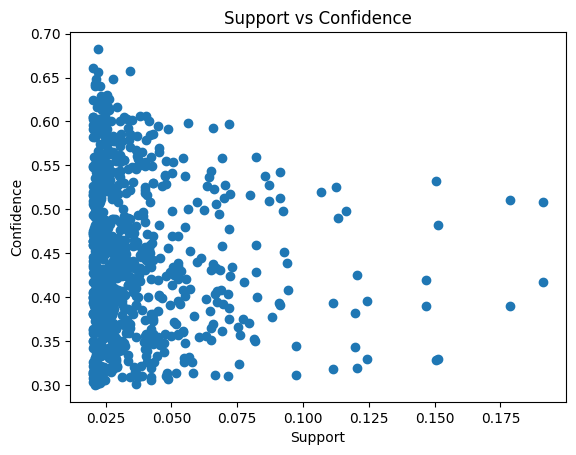

                                      antecedents  \
808            frozenset({bottled water, yogurt})   
863                  frozenset({yogurt, sausage})   
860   frozenset({rolls/buns, whole milk, yogurt})   
819              frozenset({rolls/buns, sausage})   
859  frozenset({rolls/buns, whole milk, sausage})   

                                   consequents  antecedent support  \
808  frozenset({whole milk, other vegetables})            0.066444   
863        frozenset({rolls/buns, whole milk})            0.075423   
860                       frozenset({sausage})            0.065931   
819  frozenset({whole milk, other vegetables})            0.082350   
859                        frozenset({yogurt})            0.048743   

     consequent support   support  confidence      lift  representativity  \
808            0.191380  0.022063    0.332046  1.735009               1.0   
863            0.178553  0.022832    0.302721  1.695412               1.0   
860            0.206003  0.02

In [7]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import networkx as nx

data = pd.read_csv("Groceries_dataset.csv")

transactions = data.groupby('Member_number')['itemDescription'].apply(list).values.tolist()

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_array, columns=te.columns_)

frequent_itemsets = apriori(df, min_support=0.02, use_colnames=True)

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)

rules = rules.sort_values(by='lift', ascending=False)

top_items = frequent_itemsets.sort_values(by="support", ascending=False).head(10)
plt.barh(top_items['itemsets'].astype(str), top_items['support'])
plt.xlabel("Support")
plt.ylabel("Itemsets")
plt.title("Top Frequent Itemsets")
plt.show()

G = nx.DiGraph()

for _, row in rules.head(20).iterrows():
    G.add_edge(str(set(row['antecedents'])), str(set(row['consequents'])), weight=row['lift'])

pos = nx.spring_layout(G)
edges = G.edges(data=True)
weights = [d['weight'] for (_, _, d) in edges]

nx.draw(G, pos, with_labels=True, node_size=2000, node_color="lightblue", font_size=8, width=weights)
plt.show()

plt.scatter(rules['support'], rules['confidence'])
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence")
plt.show()

print(rules.head())